# When does a cuVS ANN index pay for itself?

This output-complete notebook compares resident exact GPU search with IVF-Flat,
two IVF-PQ compression levels, and CAGRA. It focuses on the economic boundary:
the number of queries required to recover an ANN index's measured build time.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
RESULTS = Path("results/published_results.csv")
results = pd.read_csv(RESULTS)
results.shape, sorted(results["algorithm"].unique())


((90, 27), ['brute_force', 'cagra', 'ivf_flat', 'ivf_pq_balanced'])

## Evidence checks

Each row is one confirmed dataset, algorithm, batch, and parameter operating
point. ANN rows must substantiate at least one recall target across all three
fresh-process confirmation replications. `ann-not-faster` means the measured
ANN search was no faster than exact for that batch, so build amortization has
no finite answer.


In [2]:
assert results["replications"].min() == 3
assert results.loc[results["algorithm"] != "brute_force", "confirmed_target_recalls"].notna().all()
assert set(results["break_even_status"]) <= {"reference", "finite", "ann-not-faster"}
results.groupby(["rows", "dimensions", "algorithm"]).size().unstack(fill_value=0)


algorithm           brute_force  cagra  ivf_flat  ivf_pq_balanced
rows    dimensions                                               
100000  128                   4     11         7                3
1000000 128                   4      8         8                3
        384                   4      0         4                0
        768                   4      0         4                0
5000000 128                   4      8        12                2

## Search latency changes with corpus scale and batching


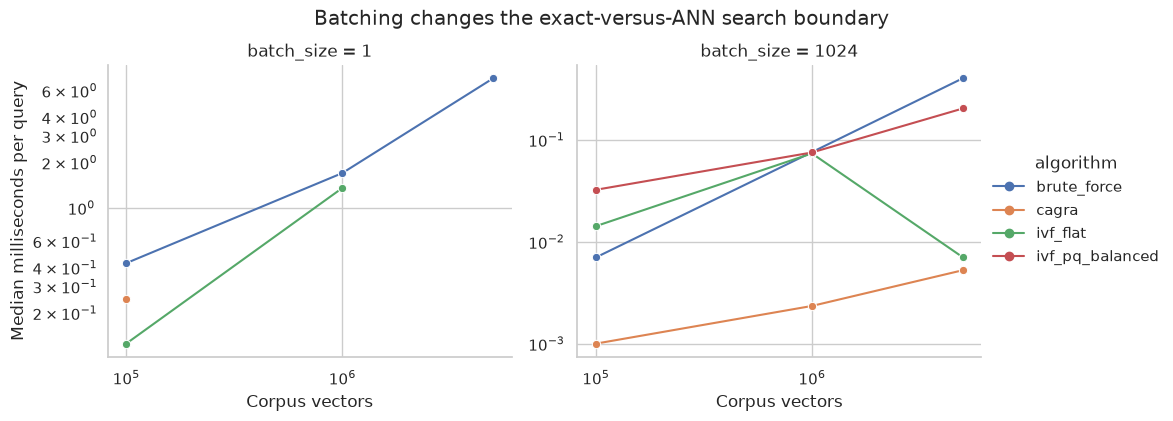

In [3]:
scale = results[(results["dimensions"] == 128) & (results["batch_size"].isin([1, 1024]))].copy()
best = (
    scale.sort_values("latency_ms_per_batch_median")
    .groupby(["rows", "algorithm", "batch_size"], as_index=False)
    .first()
)
chart = sns.relplot(
    data=best, x="rows", y="latency_ms_per_query_median", hue="algorithm",
    col="batch_size", kind="line", marker="o", height=4, aspect=1.2,
    facet_kws={"sharey": False},
)
chart.set(xscale="log", yscale="log")
chart.set_axis_labels("Corpus vectors", "Median milliseconds per query")
chart.figure.suptitle("Batching changes the exact-versus-ANN search boundary", y=1.04)
plt.show()


## Recall is an operating constraint, not a footnote


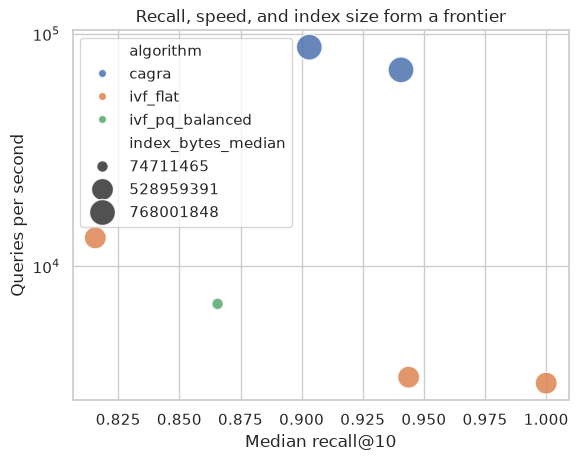

In [4]:
million = results[(results["rows"] == 1_000_000) & (results["dimensions"] == 128) & (results["batch_size"] == 32)].copy()
million = million[million["algorithm"] != "brute_force"]
sns.scatterplot(
    data=million, x="recall_at_10_median", y="queries_per_second_median",
    hue="algorithm", size="index_bytes_median", sizes=(70, 350), alpha=0.85,
)
plt.yscale("log")
plt.xlabel("Median recall@10")
plt.ylabel("Queries per second")
plt.title("Recall, speed, and index size form a frontier")
plt.show()


## The build-time break-even curve


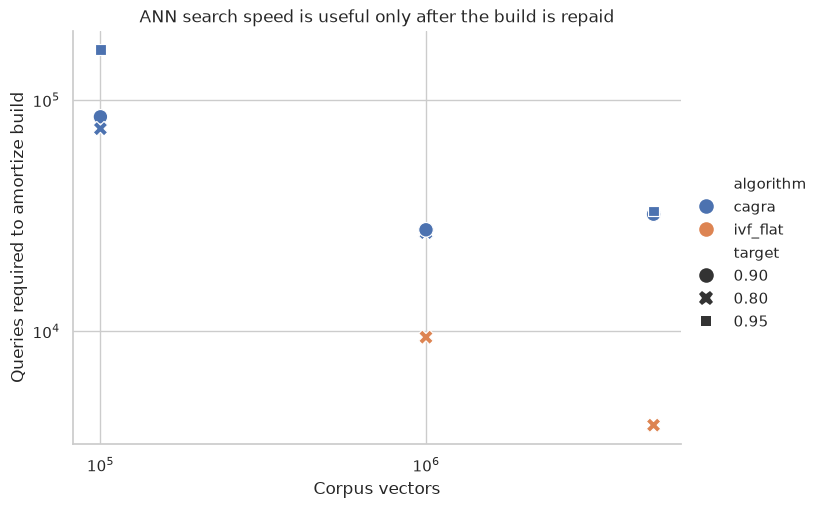

In [5]:
finite = results[
    (results["break_even_status"] == "finite")
    & (results["dimensions"] == 128)
    & (results["batch_size"] == 32)
].copy()
finite["target"] = finite["confirmed_target_recalls"].str.split(";").str[-1]
sns.relplot(
    data=finite, x="rows", y="break_even_queries", hue="algorithm",
    style="target", kind="scatter", s=110, height=5, aspect=1.5,
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Corpus vectors")
plt.ylabel("Queries required to amortize build")
plt.title("ANN search speed is useful only after the build is repaid")
plt.show()


## Dimensionality changes both compute and memory


In [6]:
dims = results[(results["rows"] == 1_000_000) & (results["batch_size"] == 32)].copy()
dims = dims.sort_values("latency_ms_per_batch_median").groupby(["dimensions", "algorithm"], as_index=False).first()
dims[["dimensions", "algorithm", "latency_ms_per_query_median", "device_memory_search_max_bytes_median", "index_bytes_median"]]


,dimensions,algorithm,latency_ms_per_query_median,device_memory_search_max_bytes_median,index_bytes_median
0,128,brute_force,0.117201,1267138560,516001186
1,128,cagra,0.011388,1757872128,768001848
2,128,ivf_flat,0.075332,1733558272,528959391
3,128,ivf_pq_balanced,0.144908,1537671168,74711465
4,384,brute_force,0.352472,2294743040,1540001186
5,384,ivf_flat,0.941593,5123801088,1570457503
6,768,brute_force,0.704376,3838246912,3076001186
7,768,ivf_flat,3.192190,8516993024,3131918239


## Reading the result

There is no universal query-count threshold. Build amortization is conditional
on corpus size, dimensionality, query batch, chosen recall target, and the ANN
family. A service with a stable, frequently queried corpus can justify a graph
or partitioned index quickly; a small or short-lived corpus can remain cheaper
to search exactly on the same GPU. Memory and recall can still disqualify the
elapsed-time winner.

The experiment is warm, resident, single-GPU search on synthetic clustered
embeddings. It does not include vector-database filtering, network ingress,
updates, concurrency, or queueing.
